In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

df = pd.read_excel('E-commerce.xlsx')

In [24]:
df.columns

Index(['c', 'device_type', 'user_id', 'session_id', 'item_id', 'item_price',
       'category', 'product_type', 'impression_time', 'app_code', 'os_version',
       'is_4G', 'is_click'],
      dtype='object')

In [25]:
print(df.head())

                    c device_type  user_id  session_id  item_id  item_price  \
0 2018-10-18 14:27:00     android    87862      268465    44459        4602   
1 2018-10-18 14:27:00     android    63410      268465    44459        3513   
2 2018-10-18 14:43:00     android    71748      268465    44459         825   
3 2018-10-18 14:46:00     android    69209      268465    44459        2355   
4 2018-10-18 14:46:00     android    62873      268465    44459        1267   

   category  product_type     impression_time  app_code    os_version  is_4G  \
0        11          3040 2018-11-15 00:00:00       422           old      0   
1        12          6822 2018-11-15 00:01:00       467        latest      1   
2        17          1619 2018-11-15 00:02:00       259  intermediate      1   
3        13          5264 2018-11-15 00:02:00       244        latest      1   
4        17         10239 2018-11-15 00:02:00       473        latest      0   

   is_click  
0         0  
1         1  
2 

In [26]:
print(df.tail())

                       c device_type  user_id  session_id  item_id  \
2020 2018-11-03 12:39:00     android     8146      284263     5754   
2021 2018-11-03 12:39:00     android    43622      284263    28621   
2022 2018-11-03 12:41:00     android    12923      284263    28621   
2023 2018-10-20 22:59:00     android    26523      418685    36253   
2024 2018-10-20 23:01:00     android    91568      418685    25054   

      item_price  category  product_type     impression_time  app_code  \
2020        2125        13          1762 2018-11-15 09:46:00       207   
2021        2874        10          9375 2018-11-15 09:46:00       207   
2022        6105        17          2637 2018-11-15 09:46:00         3   
2023        3444         7          2037 2018-11-15 09:47:00       207   
2024        2035        17          2150 2018-11-15 09:47:00       129   

     os_version  is_4G  is_click  
2020     latest      1         0  
2021     latest      1         0  
2022     latest      1       

In [27]:
df.shape

(2025, 13)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2025 entries, 0 to 2024
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   c                2025 non-null   datetime64[ns]
 1   device_type      2025 non-null   object        
 2   user_id          2025 non-null   int64         
 3   session_id       2025 non-null   int64         
 4   item_id          2025 non-null   int64         
 5   item_price       2025 non-null   int64         
 6   category         2025 non-null   int64         
 7   product_type     2025 non-null   int64         
 8   impression_time  2025 non-null   datetime64[ns]
 9   app_code         2025 non-null   int64         
 10  os_version       2025 non-null   object        
 11  is_4G            2025 non-null   int64         
 12  is_click         2025 non-null   int64         
dtypes: datetime64[ns](2), int64(9), object(2)
memory usage: 205.8+ KB


In [29]:
# Check for missing values
print(df.isnull().sum())

c                  0
device_type        0
user_id            0
session_id         0
item_id            0
item_price         0
category           0
product_type       0
impression_time    0
app_code           0
os_version         0
is_4G              0
is_click           0
dtype: int64


In [30]:
# Check for duplicate values
df.duplicated().sum()

np.int64(0)

In [31]:
# Convert 'impression_time' to datetime for processing
df['impression_time'] = pd.to_datetime(df['impression_time'])

# Extract useful features
df['hour'] = df['impression_time'].dt.hour
df['dayofweek'] = df['impression_time'].dt.dayofweek

# Drop original datetime and "c" column
df = df.drop(columns=['impression_time', 'c'])


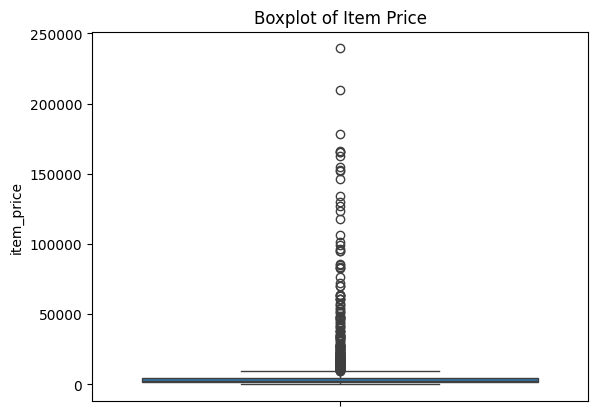

In [32]:
#boxplot before removing outliers
sns.boxplot(y='item_price', data=df)
plt.title('Boxplot of Item Price')
plt.show()

In [33]:
def handle_outliers(df, column, threshold=1, remove=False):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    if remove:
        # Return the DataFrame without outliers
        return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    else:
        # Return only the rows that are outliers
        return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

print("Before cleaning:", df.shape[0], "rows")
df = handle_outliers(df, 'item_price')
print("After cleaning:", df.shape[0], "rows")

Before cleaning: 2025 rows
After cleaning: 304 rows


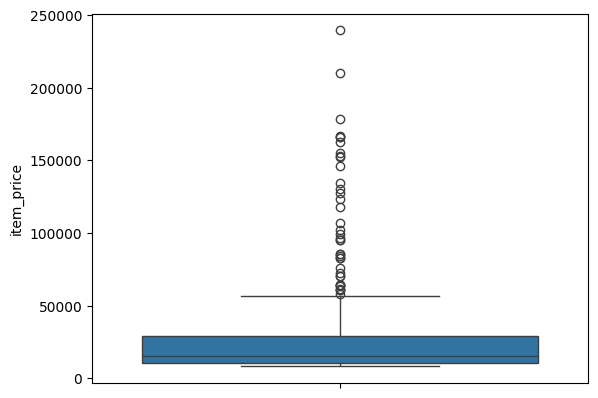

In [34]:
#boxplot after removing outliers
sns.boxplot(data=df, y='item_price')
plt.show()

In [35]:
#2.3 Split the Dataset into Train and Test

from sklearn.model_selection import train_test_split

X = df.drop('is_click', axis=1)
y = df['is_click']

# Convert categorical variables to numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [36]:
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (228, 12)
Testing set shape: (76, 12)


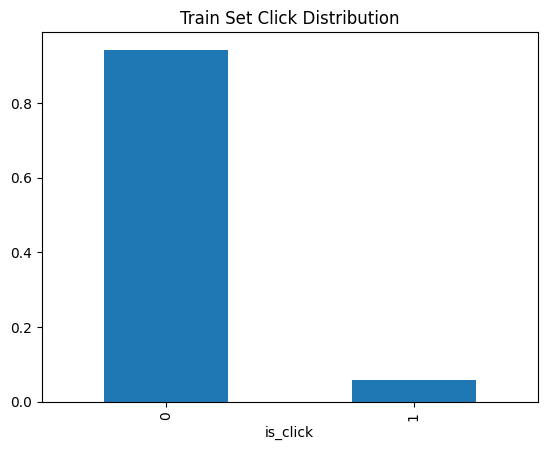

In [37]:
y_train.value_counts(normalize=True).plot(kind='bar', title='Train Set Click Distribution')
plt.show()

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Define and train models
logreg = LogisticRegression(max_iter=1000)
knn = KNeighborsClassifier()
dtree = DecisionTreeClassifier()
rf = RandomForestClassifier()
svm = SVC(kernel='linear')

# Model Dictionary
models = {
    'Logistic Regression': logreg,
    'KNN': knn,
    'Decision Tree': dtree,
    'Random Forest': rf,
    'SVM': svm
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\nModel: {name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
Accuracy: 0.9342105263157895
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Model: KNN
Accuracy: 0.9473684210526315
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Model: Decision Tree
Accuracy: 0.9078947368421053
Precision: 0.2
Recall: 0.25
F1 Score: 0.2222222222222222

Model: Random Forest
Accuracy: 0.9473684210526315
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Model: SVM
Accuracy: 0.9210526315789473
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


Accuracy: 0.9210526315789473
Precision: 0.0
Recall: 0.0
F1 Score: 0.0


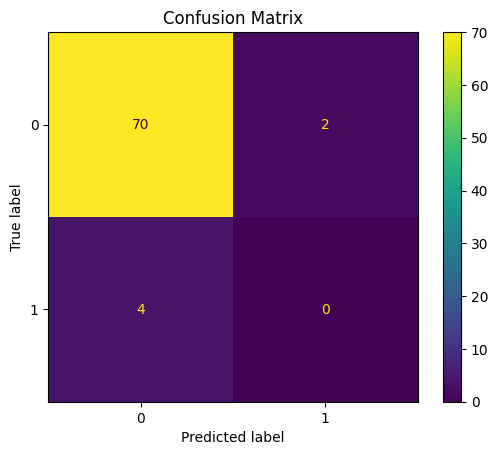

In [61]:
#2.5	Evaluate the performance of the model
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test)

# Overall Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

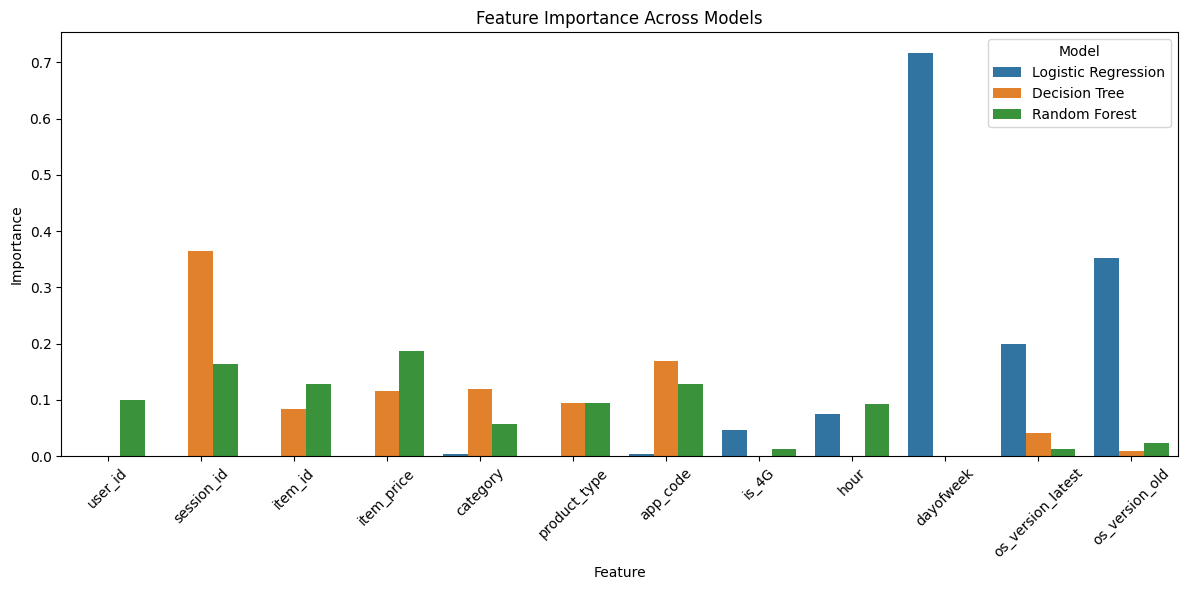

In [65]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Logistic Regression': np.abs(logreg.coef_[0]),
    'Decision Tree': dtree.feature_importances_,
    'Random Forest': rf.feature_importances_,
})

# Melt for seaborn barplot
importance_melted = importance_df.melt(id_vars='Feature', var_name='Model', value_name='Importance')

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=importance_melted, x='Feature', y='Importance', hue='Model')
plt.title('Feature Importance Across Models')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()